# Early Stage

## 1. Cai dat va khoi tao moi truong

In [1]:
# Cai dat thu vien can thiet
import subprocess, sys

for pkg in ['ultralytics', 'pandas', 'matplotlib']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'Da cai {pkg}')

In [2]:
import os
import gc
import json
import random
import shutil
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
from pathlib import Path

from ultralytics import YOLO

print(f'torch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('CANH BAO: Khong co GPU. Training se rat cham.')

torch 2.11.0+cu128 | CUDA: True
GPU: NVIDIA RTX 6000 Ada Generation


## 2. Cau hinh duong dan va tham so

In [3]:
# === Duong dan tren GPU server ===
BASE_DIR       = '/root/AIP491'
RGBT_DATA_DIR  = os.path.join(BASE_DIR, 'data', 'RGBTDronePerson')

print(f'Base dir:      {BASE_DIR}')
print(f'RGBT data:     {RGBT_DATA_DIR} | ton tai: {os.path.exists(RGBT_DATA_DIR)}')

Base dir:      /root/AIP491
RGBT data:     /root/AIP491/data/RGBTDronePerson | ton tai: True


In [ ]:
# === Tham so ===
YOLOV8N_PATH = 'yolov8n.pt' 
# Step 1 - Pretrain: yolov8n.pt (COCO pretrained) tren LLVIP pair dataset

EARLY_YOLO_DIR      = os.path.join(BASE_DIR, 'Early-fusion', 'early_yolo')
EARLY_OUTPUT_DIR    = os.path.join(BASE_DIR, 'Early-fusion', 'outputs', 'early_luong1')
LLVIP_PAIR_DIR      = os.path.join(EARLY_YOLO_DIR, 'llvip_pair')
RGBT_PAIR_DIR       = os.path.join(EARLY_YOLO_DIR, 'rgbt_pair')    # Step 2 dataset
# Su dung backbone LLVIP co san (khong can train LLVIP lai)
PRETRAIN_CKPT_PATH  = os.path.join(BASE_DIR, 'backbones', 'llvip_rgb_best.pt')

os.makedirs(EARLY_YOLO_DIR, exist_ok=True)
os.makedirs(EARLY_OUTPUT_DIR, exist_ok=True)

SEEDS         = [42, 777, 123]
NUM_EPOCHS    = 50
PATIENCE      = 2
BATCH_SIZE   = 32
IMG_SIZE      = 640    # Moi anh rieng le 640x640
NUM_WORKERS   = 4
CLASS_MAP     = {'person': 0, 'rider': 0}

print(f'EARLY_OUTPUT_DIR:   {EARLY_OUTPUT_DIR}')
print(f'LLVIP pair dir:     {LLVIP_PAIR_DIR}')
print(f'RGBT pair dir:      {RGBT_PAIR_DIR}')
print(f'Pretrain ckpt:      {PRETRAIN_CKPT_PATH}')
print(f'Seeds:              {SEEDS}')
print(f'IMG_SIZE:           {IMG_SIZE}')

EARLY_OUTPUT_DIR:   /root/AIP491/Early-fusion/outputs/early_luong1
RGBT pair dir:      /root/AIP491/Early-fusion/early_yolo/rgbt_pair
Pretrain ckpt:      /root/AIP491/backbones/llvip_rgb_best.pt
Seeds:              [42, 777, 123]
IMG_SIZE:           640


## 3. Phan tich du lieu (EDA)

In [ ]:
def parse_voc_xml(xml_path):
    """Doc annotation VOC XML."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find("size")
    w_img = int(size.find("width").text)
    h_img = int(size.find("height").text)
    objects = []
    for obj in root.findall("object"):
        cls = obj.find("name").text.lower()
        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)
        objects.append((cls, xmin, ymin, xmax, ymax, w_img, h_img))
    return objects


# EDA LLVIP: bo qua (khong can LLVIP data khi dung backbone co san)
print("Bo qua EDA LLVIP. Ham parse_voc_xml da san sang.")


## 4. Tao LLVIP Dataset (cho Step 1 Pretrain)

- LLVIP RGB: visible/train/ + Thermal: infrared/train/ + Annotations/*.xml
- Class 'person' -> 0

In [ ]:
def voc_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h):
    cx = (xmin + xmax) / 2.0 / img_w
    cy = (ymin + ymax) / 2.0 / img_h
    w  = (xmax - xmin) / img_w
    h  = (ymax - ymin) / img_h
    return [min(max(v, 0.0), 1.0) for v in [cx, cy, w, h]]


def create_pair_dataset(rgb_dir, thr_dir, ann_dir, out_dir,
                        split_name, class_map, target_size=640):
    """Tao pair dataset: copy ca RGB va Thermal vao chung 1 folder.

    Moi scene co 2 anh (stem_rgb.jpg + stem_thr.jpg) voi cung label.
    Tang gap doi data so voi train tren 1 modality.
    """
    img_out = os.path.join(out_dir, 'images', split_name)
    lbl_out = os.path.join(out_dir, 'labels', split_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    ann_path = Path(ann_dir)
    xml_files = sorted(ann_path.glob('*.xml'))
    stats = {'ok': 0, 'no_person': 0, 'missing_img': 0, 'errors': 0}

    for xml_file in xml_files:
        stem = xml_file.stem
        try:
            objs = parse_voc_xml(xml_file)
        except Exception:
            stats['errors'] += 1
            continue

        person_objs = [o for o in objs if o[0] in class_map]
        if not person_objs:
            stats['no_person'] += 1
            continue

        # Tim anh RGB va Thermal
        rgb_img_path = None
        for ext in ['.jpg', '.png', '.jpeg']:
            candidate = Path(rgb_dir) / f'{stem}{ext}'
            if candidate.exists():
                rgb_img_path = candidate
                break
        thr_img_path = None
        for ext in ['.jpg', '.png', '.jpeg']:
            candidate = Path(thr_dir) / f'{stem}{ext}'
            if candidate.exists():
                thr_img_path = candidate
                break

        if rgb_img_path is None or thr_img_path is None:
            stats['missing_img'] += 1
            continue

        rgb_img = cv2.imread(str(rgb_img_path))
        thr_img = cv2.imread(str(thr_img_path))
        if rgb_img is None or thr_img is None:
            stats['missing_img'] += 1
            continue

        # Resize ve 640x640
        rgb_resized = cv2.resize(rgb_img, (target_size, target_size))
        if len(thr_img.shape) == 2:
            thr_img = cv2.cvtColor(thr_img, cv2.COLOR_GRAY2BGR)
        thr_resized = cv2.resize(thr_img, (target_size, target_size))

        # Tao YOLO label (dung chung cho ca RGB va Thermal)
        label_lines = []
        for cls, xmin, ymin, xmax, ymax, img_w, img_h in person_objs:
            cx, cy, w, h = voc_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h)
            if w > 0 and h > 0:
                label_lines.append(f'{class_map[cls]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')

        if not label_lines:
            stats['no_person'] += 1
            continue

        label_content = '\n'.join(label_lines) + '\n'

        # Luu RGB: stem_rgb.jpg + stem_rgb.txt
        cv2.imwrite(os.path.join(img_out, f'{stem}_rgb.jpg'), rgb_resized)
        with open(os.path.join(lbl_out, f'{stem}_rgb.txt'), 'w') as lf:
            lf.write(label_content)

        # Luu Thermal: stem_thr.jpg + stem_thr.txt
        cv2.imwrite(os.path.join(img_out, f'{stem}_thr.jpg'), thr_resized)
        with open(os.path.join(lbl_out, f'{stem}_thr.txt'), 'w') as lf:
            lf.write(label_content)

        stats['ok'] += 1

    print(f'  {split_name}: {stats["ok"]} pairs -> {stats["ok"] * 2} images, '
          f'no_person={stats["no_person"]}, missing={stats["missing_img"]}, errors={stats["errors"]}')
    return stats


# Kiem tra LLVIP pair da tao chua
llvip_train_imgs = list(Path(LLVIP_PAIR_DIR, 'images', 'train').glob('*.jpg')) \
    if os.path.exists(os.path.join(LLVIP_PAIR_DIR, 'images', 'train')) else []

if len(llvip_train_imgs) > 0:
    print(f'LLVIP pair da ton tai ({len(llvip_train_imgs)} anh train). Bo qua tao moi.')
else:
    print('Tao LLVIP pair dataset...')
    llvip_class_map = {'person': 0}   # LLVIP chi co 'person'

    create_pair_dataset(
        rgb_dir    = str(Path(LLVIP_DATA_DIR) / 'visible' / 'train'),
        thr_dir    = str(Path(LLVIP_DATA_DIR) / 'infrared' / 'train'),
        ann_dir    = str(Path(LLVIP_DATA_DIR) / 'Annotations'),
        out_dir    = LLVIP_PAIR_DIR,
        split_name = 'train',
        class_map  = llvip_class_map
    )
    # Kiem tra LLVIP co val set khong
    llvip_vis_val = Path(LLVIP_DATA_DIR) / 'visible' / 'val'
    llvip_thr_val = Path(LLVIP_DATA_DIR) / 'infrared' / 'val'
    llvip_ann_val = Path(LLVIP_DATA_DIR) / 'Annotations_val'
    if llvip_vis_val.exists() and llvip_ann_val.exists():
        create_pair_dataset(
            rgb_dir    = str(llvip_vis_val),
            thr_dir    = str(llvip_thr_val),
            ann_dir    = str(llvip_ann_val),
            out_dir    = LLVIP_PAIR_DIR,
            split_name = 'val',
            class_map  = llvip_class_map
        )
    else:
        # Neu khong co val, dung 10% train lam val
        print('Khong co LLVIP val set rieng. Su dung 10% train lam val.')
        all_train_imgs = sorted(Path(LLVIP_PAIR_DIR, 'images', 'train').glob('*.jpg'))
        n_val = max(1, int(len(all_train_imgs) * 0.1))
        os.makedirs(os.path.join(LLVIP_PAIR_DIR, 'images', 'val'), exist_ok=True)
        os.makedirs(os.path.join(LLVIP_PAIR_DIR, 'labels', 'val'), exist_ok=True)
        # Di chuyen theo pair (rgb + thr cung stem)
        moved_stems = set()
        count = 0
        for img_p in all_train_imgs:
            base_stem = img_p.stem.replace('_rgb', '').replace('_thr', '')
            if base_stem in moved_stems:
                continue
            if count >= n_val // 2:
                break
            for suffix in ['_rgb', '_thr']:
                src_img = os.path.join(LLVIP_PAIR_DIR, 'images', 'train', f'{base_stem}{suffix}.jpg')
                src_lbl = os.path.join(LLVIP_PAIR_DIR, 'labels', 'train', f'{base_stem}{suffix}.txt')
                dst_img = os.path.join(LLVIP_PAIR_DIR, 'images', 'val', f'{base_stem}{suffix}.jpg')
                dst_lbl = os.path.join(LLVIP_PAIR_DIR, 'labels', 'val', f'{base_stem}{suffix}.txt')
                if os.path.exists(src_img) and not os.path.exists(dst_img):
                    shutil.copy2(src_img, dst_img)
                if os.path.exists(src_lbl) and not os.path.exists(dst_lbl):
                    shutil.copy2(src_lbl, dst_lbl)
            moved_stems.add(base_stem)
            count += 1
        print(f'  Da tach {count} pairs ({count * 2} anh) lam val set.')

# Thong ke
for split in ['train', 'val']:
    d = os.path.join(LLVIP_PAIR_DIR, 'images', split)
    n_img = len(list(Path(d).glob('*.jpg'))) if os.path.exists(d) else 0
    d_lbl = os.path.join(LLVIP_PAIR_DIR, 'labels', split)
    n_lbl = len(list(Path(d_lbl).glob('*.txt'))) if os.path.exists(d_lbl) else 0
    print(f'LLVIP pair {split}: images={n_img}, labels={n_lbl}')

## 5. Tao RGBTDronePerson Side-by-Side Dataset (cho Step 2 Finetune)

- visible/ (RGB) + thermal/ (Thermal) -> 1280x640
- annotation/ VOC XML, person+rider -> class 0

In [7]:
# Kiem tra RGBT pair da tao chua
rgbt_train_imgs = list(Path(RGBT_PAIR_DIR, 'images', 'train').glob('*.jpg')) \
    if os.path.exists(os.path.join(RGBT_PAIR_DIR, 'images', 'train')) else []

if len(rgbt_train_imgs) > 0:
    print(f'RGBT pair da ton tai ({len(rgbt_train_imgs)} anh train). Bo qua tao moi.')
else:
    print('Tao RGBTDronePerson pair dataset...')
    for split in ['train', 'val']:
        create_pair_dataset(
            rgb_dir    = str(Path(RGBT_DATA_DIR) / split / 'visible'),
            thr_dir    = str(Path(RGBT_DATA_DIR) / split / 'thermal'),
            ann_dir    = str(Path(RGBT_DATA_DIR) / split / 'annotation'),
            out_dir    = RGBT_PAIR_DIR,
            split_name = split,
            class_map  = CLASS_MAP
        )

# Thong ke
for split in ['train', 'val']:
    d = os.path.join(RGBT_PAIR_DIR, 'images', split)
    n_img = len(list(Path(d).glob('*.jpg'))) if os.path.exists(d) else 0
    d_lbl = os.path.join(RGBT_PAIR_DIR, 'labels', split)
    n_lbl = len(list(Path(d_lbl).glob('*.txt'))) if os.path.exists(d_lbl) else 0
    print(f'RGBT pair {split}: images={n_img}, labels={n_lbl}')

RGBT pair da ton tai (9520 anh train). Bo qua tao moi.
RGBT pair train: images=9520, labels=9520
RGBT pair val: images=2414, labels=2414


## 6. Truc quan hoa mau du lieu Pair

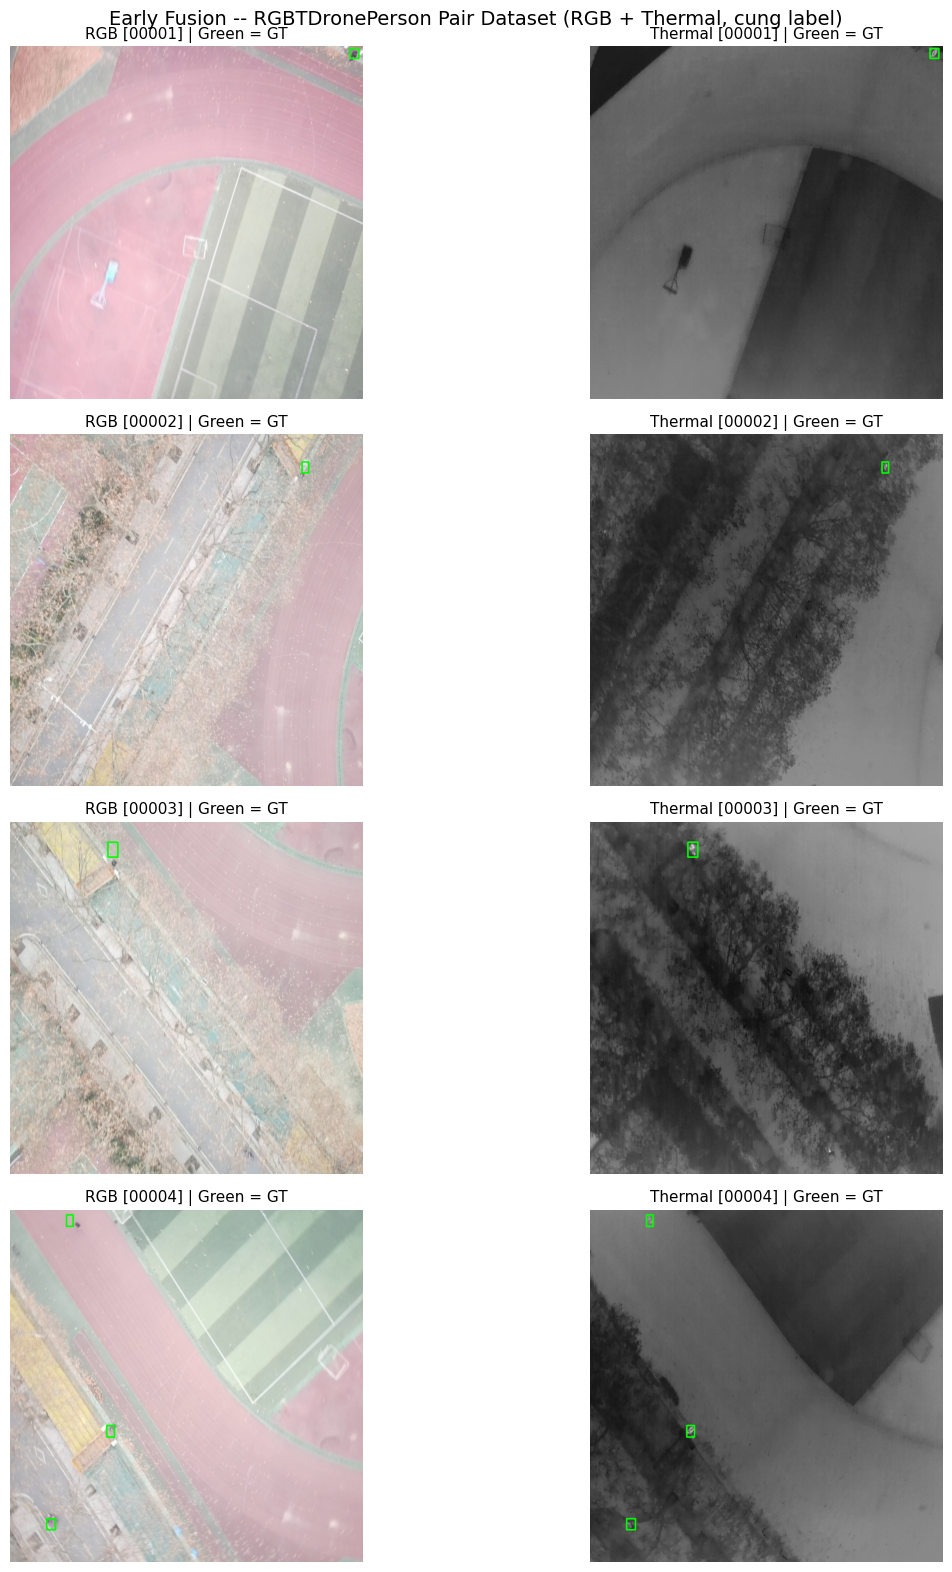

In [8]:
# Hien thi mau pair tu RGBT dataset (RGB va Thermal cung scene)
train_dir = os.path.join(RGBT_PAIR_DIR, 'images', 'train')
sample_stems = []
if os.path.exists(train_dir):
    all_files = sorted(Path(train_dir).glob('*_rgb.jpg'))
    sample_stems = [f.stem.replace('_rgb', '') for f in all_files[:4]]

if not sample_stems:
    print('Khong tim thay anh pair RGBT.')
else:
    fig, axes = plt.subplots(len(sample_stems), 2, figsize=(14, 4 * len(sample_stems)))
    if len(sample_stems) == 1:
        axes = [axes]

    for row, stem in enumerate(sample_stems):
        for col, (suffix, title) in enumerate([('_rgb', 'RGB'), ('_thr', 'Thermal')]):
            img_path = os.path.join(train_dir, f'{stem}{suffix}.jpg')
            img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]

            # Ve GT boxes
            lbl_path = os.path.join(RGBT_PAIR_DIR, 'labels', 'train', f'{stem}{suffix}.txt')
            if os.path.exists(lbl_path):
                with open(lbl_path) as lf:
                    for line in lf:
                        v = list(map(float, line.strip().split()))
                        if len(v) == 5:
                            cx, cy, bw, bh = v[1], v[2], v[3], v[4]
                            x1 = int((cx - bw / 2) * w)
                            y1 = int((cy - bh / 2) * h)
                            x2 = int((cx + bw / 2) * w)
                            y2 = int((cy + bh / 2) * h)
                            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            axes[row][col].imshow(img)
            axes[row][col].set_title(f'{title} [{stem}] | Green = GT', fontsize=11)
            axes[row][col].axis('off')

    plt.suptitle('Early Fusion -- RGBTDronePerson Pair Dataset (RGB + Thermal, cung label)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 7. Tao YAML config cho YOLO

In [ ]:
# YAML cho LLVIP pair (Step 1 pretrain)
llvip_yaml_path = os.path.join(LLVIP_PAIR_DIR, 'llvip_pair_data.yaml')
llvip_yaml_content = (
    f'path: {LLVIP_PAIR_DIR}\n'
    'train: images/train\n'
    'val: images/val\n'
    '\n'
    'nc: 1\n'
    "names: ['person']\n"
)
with open(llvip_yaml_path, 'w') as yf:
    yf.write(llvip_yaml_content)
print(f'Da tao: {llvip_yaml_path}')

# YAML cho RGBT pair (Step 2 finetune)
rgbt_yaml_path = os.path.join(RGBT_PAIR_DIR, 'rgbt_pair_data.yaml')
rgbt_yaml_content = (
    f'path: {RGBT_PAIR_DIR}\n'
    'train: images/train\n'
    'val: images/val\n'
    '\n'
    'nc: 1\n'
    "names: ['person']\n"
)
with open(rgbt_yaml_path, 'w') as yf:
    yf.write(rgbt_yaml_content)
print(f'Da tao: {rgbt_yaml_path}')

In [10]:
def set_seed(seed):
    """Dat random seed cho reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False

## 8. STEP 1: Pretrain tren LLVIP

- Bat dau tu yolov8n.pt (COCO pretrained, 3-channel RGB)
- Train mot lan duy nhat (khong dung seeds)
- Luu best checkpoint lam early_llvip_pretrained.pt

In [ ]:
# STEP 1: Pretrain tren LLVIP pair dataset
if os.path.exists(PRETRAIN_CKPT_PATH):
    print(f'STEP 1: Da co pretrain checkpoint: {PRETRAIN_CKPT_PATH}')
    print('Bo qua pretrain.')
else:
    print('STEP 1: Bat dau pretrain tren LLVIP pair dataset...')
    print(f'  Bat dau tu: {YOLOV8N_PATH} (YOLOv8n COCO pretrained)')

    set_seed(42)
    pretrain_model = YOLO(YOLOV8N_PATH)
    pretrain_run_dir = os.path.join(EARLY_OUTPUT_DIR, 'pretrain_llvip')

    pretrain_model.train(
        data=llvip_yaml_path,
        epochs=NUM_EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=0,
        workers=NUM_WORKERS,
        project=EARLY_OUTPUT_DIR,
        name='pretrain_llvip',
        pretrained=True,
        patience=PATIENCE,
        save=True,
        verbose=True,
        seed=42,
        exist_ok=True
    )

    # Copy best.pt sang ten co the nhan biet
    pretrain_best = os.path.join(EARLY_OUTPUT_DIR, 'pretrain_llvip', 'weights', 'best.pt')
    if os.path.exists(pretrain_best):
        shutil.copy2(pretrain_best, PRETRAIN_CKPT_PATH)
        print(f'Da luu pretrain checkpoint: {PRETRAIN_CKPT_PATH}')
    else:
        print(f'CANH BAO: Khong tim thay {pretrain_best}')

    del pretrain_model
    torch.cuda.empty_cache()
    gc.collect()

print(f'STEP 1 hoan thanh. Pretrain ckpt: {PRETRAIN_CKPT_PATH} | ton tai: {os.path.exists(PRETRAIN_CKPT_PATH)}')

## 9. STEP 2: Finetune tren RGBTDronePerson (3 Seeds)

- Bat dau tu early_llvip_pretrained.pt (ket qua Step 1)
- 3 seeds: 42, 777, 123
- Resume: kiem tra checkpoint ton tai

In [14]:
# STEP 2: Finetune tren RGBT (3 seeds)
all_results = {}

if not os.path.exists(PRETRAIN_CKPT_PATH):
    print(f'CANH BAO: Chua co pretrain checkpoint {PRETRAIN_CKPT_PATH}. Chay STEP 1 truoc.')
else:
    for seed_idx, SEED in enumerate(SEEDS):
        seed_dir     = os.path.join(EARLY_OUTPUT_DIR, f'seed_{SEED}')
        os.makedirs(seed_dir, exist_ok=True)
        results_path = os.path.join(seed_dir, 'early_results.json')
        best_path    = os.path.join(seed_dir, 'finetune_rgbt', 'weights', 'best.pt')

        # Resume: da co ket qua eval -> bo qua toan bo seed nay

        print(f'\n{"="*60}')
        print(f'  STEP 2 -- SEED {SEED} ({seed_idx + 1}/{len(SEEDS)})')
        print(f'{"="*60}')

        if os.path.exists(best_path):
            print(f'  Da co checkpoint, bo qua training (se chay eval).')
        else:
            set_seed(SEED)
            print(f'  Finetune tu: {PRETRAIN_CKPT_PATH}')
            finetune_model = YOLO(PRETRAIN_CKPT_PATH)
            finetune_model.train(
                data=rgbt_yaml_path,
                epochs=NUM_EPOCHS,
                imgsz=IMG_SIZE,
                batch=BATCH_SIZE,
                device=0,
                workers=NUM_WORKERS,
                project=seed_dir,
                name='finetune_rgbt',
                pretrained=True,
                patience=PATIENCE,
                save=True,
                verbose=True,
                seed=SEED,
                exist_ok=True
            )
            del finetune_model
            torch.cuda.empty_cache()
            gc.collect()

        # Danh gia bang YOLO built-in val tren RGBT val set
        if os.path.exists(best_path):
            print(f'  Danh gia model: {best_path}')
            eval_model  = YOLO(best_path)
            val_results = eval_model.val(
                data=rgbt_yaml_path,
                split='val',
                imgsz=IMG_SIZE,
                batch=BATCH_SIZE,
                device=0,
                verbose=False
            )

            mp  = float(val_results.box.mp)
            mr  = float(val_results.box.mr)
            f1  = float(2 * mp * mr / (mp + mr + 1e-9))
            metrics = {
                'precision': mp,
                'recall':    mr,
                'f1':        f1,
                'map50':     float(val_results.box.map50),
                'map50_95':  float(val_results.box.map)
            }
            all_results[SEED] = metrics

            with open(results_path, 'w') as rf:
                json.dump(metrics, rf, indent=2)

            print(f'  Precision:    {metrics["precision"]:.4f}')
            print(f'  Recall:       {metrics["recall"]:.4f}')
            print(f'  F1:           {metrics["f1"]:.4f}')
            print(f'  mAP@0.5:      {metrics["map50"]:.4f}')
            print(f'  mAP@[.5:.95]: {metrics["map50_95"]:.4f}')

            del eval_model
            torch.cuda.empty_cache()
            gc.collect()

print(f'\nDa hoan thanh {len(all_results)}/{len(SEEDS)} seeds.')


  STEP 2 -- SEED 42 (1/3)
  Da co checkpoint, bo qua training (se chay eval).
  Danh gia model: /root/AIP491/Early-fusion/outputs/early_luong1/seed_42/finetune_rgbt/weights/best.pt
Ultralytics 8.4.41 🚀 Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48520MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 927.5±536.8 MB/s, size: 152.3 KB)
val: Scanning /root/AIP491/Early-fusion/early_yolo/rgbt_pair/labels/val.cache... 2414 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2414/2414 194.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 76/76 3.3s/it 4:080.1s
                   all       2414      24912      0.461      0.291      0.255     0.0835
Speed: 54.1ms preprocess, 13.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /root/AIP491/Early-stage/runs/detect/val
  Precision:    0.4611


In [21]:
from ultralytics import YOLO
import os

os.chdir("/root/AIP491")

SEEDS = [42, 123, 999]

for SEED in SEEDS:
    best_path = f"/root/AIP491/Early-fusion/outputs/early_luong1/seed_{SEED}/finetune_rgbt/weights/best.pt"

    if not os.path.exists(best_path):
        print("missing:", SEED)
        continue

    print("\nSEED", SEED)
    model = YOLO(best_path)
    r = model.val(
        data=rgbt_yaml_path,
        split="val",
        device=0,
        project="/root/AIP491/Early-fusion/outputs/val_fix",
        name=f"seed_{SEED}",
        exist_ok=True
    )
    print("mAP50:", r.box.map50)


SEED 42
Ultralytics 8.4.41 🚀 Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48520MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 655.5±167.6 MB/s, size: 137.8 KB)
val: Scanning /root/AIP491/Early-fusion/early_yolo/rgbt_pair/labels/val.cache... 2414 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2414/2414 266.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 151/151 1.8s/it 4:30<0.1s
                   all       2414      24912      0.461      0.291      0.255     0.0835
Speed: 0.6ms preprocess, 0.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /root/AIP491/Early-fusion/outputs/val_fix/seed_42
mAP50: 0.25483042718723864
missing: 123
missing: 999


## 10. Bang tong hop ket qua

In [15]:
print(f'\n{"="*70}')
print(f'  BANG TONG HOP -- Early Fusion (Pair-based, LLVIP pretrained)')
print(f'{"="*70}')
print(f'{"Seed":<8} {"Precision":>10} {"Recall":>10} {"F1":>10} {"mAP@0.5":>10} {"mAP@[.5:.95]":>14}')
print(f'{"="*62}')

for seed in SEEDS:
    if seed in all_results:
        m = all_results[seed]
        print(f' {seed:<7} {m["precision"]:>10.4f} {m["recall"]:>10.4f} {m["f1"]:>10.4f} '
              f'{m["map50"]:>10.4f} {m["map50_95"]:>14.4f}')

if len(all_results) >= 2:
    print(f'{"-"*62}')
    for metric_name, key in [('Precision', 'precision'), ('Recall', 'recall'), ('F1', 'f1'),
                              ('mAP@0.5', 'map50'), ('mAP@[.5:.95]', 'map50_95')]:
        vals = [all_results[s][key] for s in SEEDS if s in all_results]
        print(f'  {metric_name:<14}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}')
print(f'{"="*70}')


  BANG TONG HOP -- Early Fusion (Pair-based, LLVIP pretrained)
Seed      Precision     Recall         F1    mAP@0.5   mAP@[.5:.95]
 42          0.4611     0.2906     0.3565     0.2548         0.0835
 777         0.4625     0.2848     0.3526     0.2515         0.0826
 123         0.4611     0.2906     0.3565     0.2548         0.0835
--------------------------------------------------------------
  Precision     : 0.4616 +/- 0.0006
  Recall        : 0.2887 +/- 0.0027
  F1            : 0.3552 +/- 0.0019
  mAP@0.5       : 0.2537 +/- 0.0016
  mAP@[.5:.95]  : 0.0832 +/- 0.0004


## 11. Bieu do Loss (tu YOLO training)

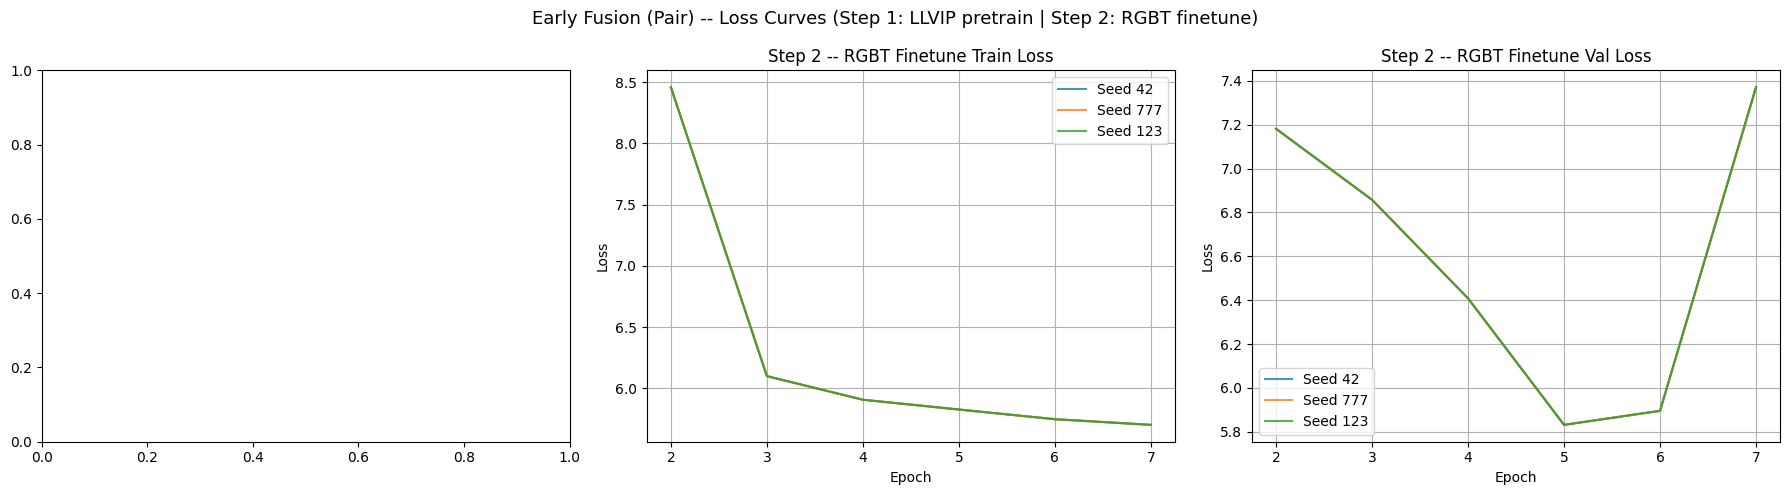

In [16]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Step 1: Pretrain LLVIP
pretrain_csv = os.path.join(EARLY_OUTPUT_DIR, 'pretrain_llvip', 'results.csv')
if os.path.exists(pretrain_csv):
    df_pre = pd.read_csv(pretrain_csv)
    df_pre.columns = [c.strip() for c in df_pre.columns]
    ep = df_pre['epoch'] + 1 if 'epoch' in df_pre.columns else range(1, len(df_pre) + 1)
    if 'train/box_loss' in df_pre.columns:
        axes[0].plot(ep, df_pre['train/box_loss'] + df_pre['train/cls_loss'] + df_pre['train/dfl_loss'],
                     color='gray', alpha=0.9, label='Train')
    if 'val/box_loss' in df_pre.columns:
        axes[0].plot(ep, df_pre['val/box_loss'] + df_pre['val/cls_loss'] + df_pre['val/dfl_loss'],
                     color='gray', linestyle='--', alpha=0.9, label='Val')
    axes[0].set(title='Step 1 -- LLVIP Pretrain Loss', xlabel='Epoch', ylabel='Loss')
    axes[0].legend(); axes[0].grid(True)

# Step 2: Finetune RGBT -- Train + Val Loss
for i, SEED in enumerate(SEEDS):
    csv_path = os.path.join(EARLY_OUTPUT_DIR, f'seed_{SEED}', 'finetune_rgbt', 'results.csv')
    if not os.path.exists(csv_path):
        continue
    df_res = pd.read_csv(csv_path)
    df_res.columns = [c.strip() for c in df_res.columns]
    ep = df_res['epoch'] + 1 if 'epoch' in df_res.columns else range(1, len(df_res) + 1)

    if 'train/box_loss' in df_res.columns:
        total_train = df_res['train/box_loss'] + df_res['train/cls_loss'] + df_res['train/dfl_loss']
        axes[1].plot(ep, total_train, color=colors[i], alpha=0.8, label=f'Seed {SEED}')

    if 'val/box_loss' in df_res.columns:
        total_val = df_res['val/box_loss'] + df_res['val/cls_loss'] + df_res['val/dfl_loss']
        axes[2].plot(ep, total_val, color=colors[i], alpha=0.8, label=f'Seed {SEED}')

axes[1].set(title='Step 2 -- RGBT Finetune Train Loss', xlabel='Epoch', ylabel='Loss')
axes[1].legend(); axes[1].grid(True)
axes[2].set(title='Step 2 -- RGBT Finetune Val Loss', xlabel='Epoch', ylabel='Loss')
axes[2].legend(); axes[2].grid(True)

plt.suptitle('Early Fusion (Pair) -- Loss Curves (Step 1: LLVIP pretrain | Step 2: RGBT finetune)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(EARLY_OUTPUT_DIR, 'loss_curves_all_seeds.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Luu ket qua va truc quan hoa

Da luu metrics tai: /root/AIP491/Early-fusion/outputs/early_luong1/metrics_summary.csv


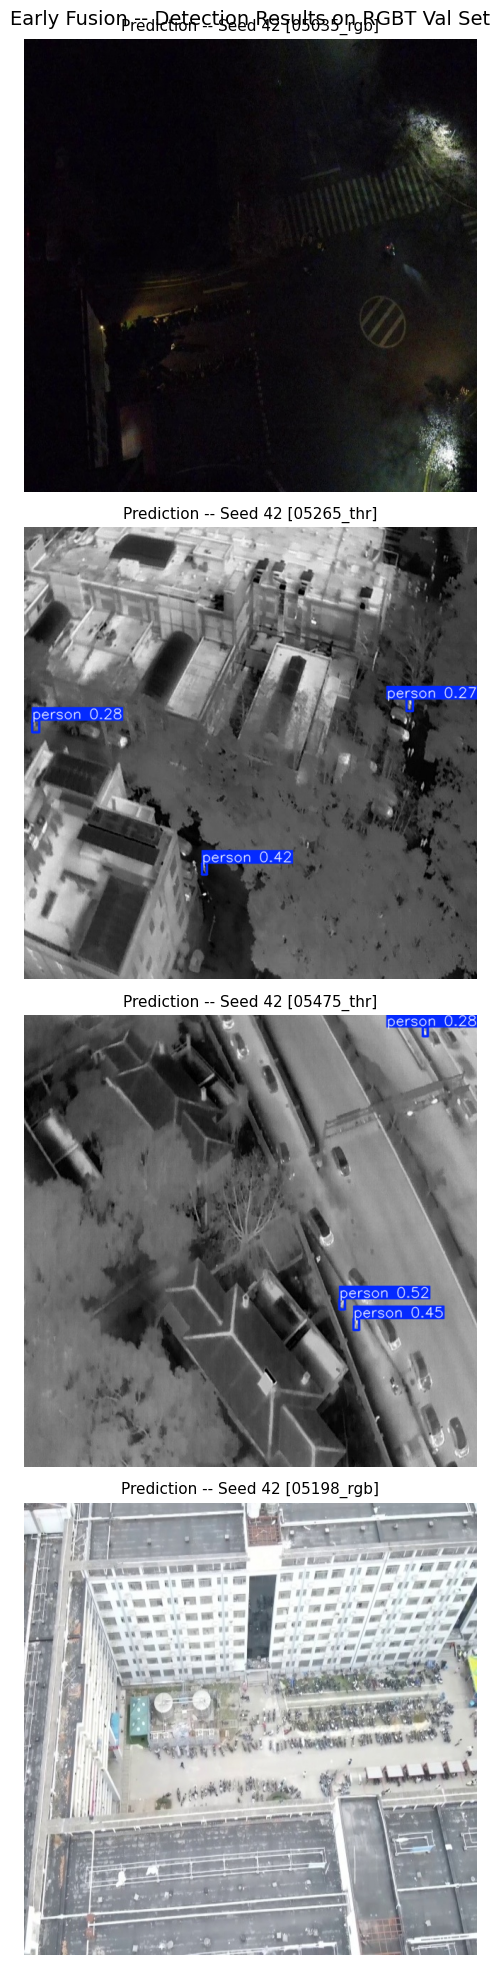


Hoan thanh -- Early Fusion (Pair-based).


In [17]:
import csv

csv_path = os.path.join(EARLY_OUTPUT_DIR, 'metrics_summary.csv')
with open(csv_path, 'w', newline='') as cf:
    writer = csv.writer(cf)
    writer.writerow(['Seed', 'Precision', 'Recall', 'F1', 'mAP@0.5', 'mAP@[.5:.95]'])
    for seed in SEEDS:
        if seed in all_results:
            m = all_results[seed]
            writer.writerow([seed,
                             f'{m["precision"]:.4f}', f'{m["recall"]:.4f}',
                             f'{m["f1"]:.4f}',        f'{m["map50"]:.4f}',
                             f'{m["map50_95"]:.4f}'])
    if len(all_results) >= 2:
        means = {k: np.mean([all_results[s][k] for s in SEEDS if s in all_results])
                 for k in ['precision', 'recall', 'f1', 'map50', 'map50_95']}
        stds  = {k: np.std([all_results[s][k] for s in SEEDS if s in all_results])
                 for k in ['precision', 'recall', 'f1', 'map50', 'map50_95']}
        writer.writerow(['Mean',
                         f'{means["precision"]:.4f}', f'{means["recall"]:.4f}',
                         f'{means["f1"]:.4f}',        f'{means["map50"]:.4f}',
                         f'{means["map50_95"]:.4f}'])
        writer.writerow(['Std',
                         f'{stds["precision"]:.4f}', f'{stds["recall"]:.4f}',
                         f'{stds["f1"]:.4f}',        f'{stds["map50"]:.4f}',
                         f'{stds["map50_95"]:.4f}'])

print(f'Da luu metrics tai: {csv_path}')

# Truc quan hoa inference
best_seed = SEEDS[0]
best_path = os.path.join(EARLY_OUTPUT_DIR, f'seed_{best_seed}', 'finetune_rgbt', 'weights', 'best.pt')

if os.path.exists(best_path):
    val_imgs   = sorted(Path(RGBT_PAIR_DIR, 'images', 'val').glob('*.jpg'))
    sample_idx = np.random.choice(len(val_imgs), size=min(4, len(val_imgs)), replace=False)

    model = YOLO(best_path)
    fig, axes = plt.subplots(len(sample_idx), 1, figsize=(16, 5 * len(sample_idx)))
    if len(sample_idx) == 1:
        axes = [axes]

    for row, idx in enumerate(sample_idx):
        img_path  = str(val_imgs[idx])
        results   = model.predict(source=img_path, conf=0.25, iou=0.45, imgsz=IMG_SIZE, verbose=False)
        annotated = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

        axes[row].imshow(annotated)
        axes[row].set_title(f'Prediction -- Seed {best_seed} [{val_imgs[idx].stem}]', fontsize=11)
        axes[row].axis('off')

    plt.suptitle('Early Fusion -- Detection Results on RGBT Val Set', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(EARLY_OUTPUT_DIR, 'inference_viz.png'), dpi=150, bbox_inches='tight')
    plt.show()

    del model
    torch.cuda.empty_cache()
else:
    print(f'Khong tim thay model: {best_path}')

print('\nHoan thanh -- Early Fusion (Pair-based).')